# Task 4B: SEAL-Augmented LoRA — UHCS Microstructure

Image + Prompt → CoT Description + JSON

GPT-4.1 generates answer-conditioned reasoning for each training image.
Same images as Direct, but 4 examples per image. 40 epochs, lr=2e-5.

## Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import json, re, time, torch, gc, random, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from config import *

random.seed(SEED)
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Step 1: Select Training Images (same seed = same selection as Direct)

In [2]:
with open(TRAIN_MANIFEST) as f:
    train_pool = json.load(f)
print(f'Train pool: {len(train_pool)} images')

by_class = defaultdict(list)
for e in train_pool:
    by_class[e['class']].append(e)

train_data = []
for cls in CLASSES:
    available = by_class[cls]
    n_select = min(IMAGES_PER_CLASS, len(available))
    random.shuffle(available)
    selected = available[:n_select]
    train_data.extend(selected)
    print(f'{cls}: {n_select}/{len(available)} selected')

print(f'\nTotal training images: {len(train_data)}')

Train pool: 478 images
spheroidite: 6/298 selected
network: 6/81 selected
spheroidite+widmanstatten: 6/62 selected
pearlite+spheroidite: 6/23 selected
pearlite: 6/12 selected

Total training images: 30


## Step 2: Generate CoT Descriptions via GPT-4.1

In [3]:
from openai import AzureOpenAI

API_KEY = '871a30b46ebf4297a8938ff5fca23646'
client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT, api_key=API_KEY, api_version=AZURE_API_VERSION)
print(f'GPT-4.1 client ready (key set: {bool(API_KEY)})')

GPT-4.1 client ready (key set: True)


In [4]:
def encode_image(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

def generate_cot(image_path, microconstituent, magnification='unknown'):
    img_b64 = encode_image(image_path)
    resp = client.chat.completions.create(
        model=AZURE_DEPLOYMENT, temperature=0.7, max_completion_tokens=512,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{img_b64}'}},
            {'type': 'text', 'text': make_seal_prompt(microconstituent, magnification)},
        ]}])
    return resp.choices[0].message.content.strip()

print('CoT generation ready.')

CoT generation ready.


In [5]:
COT_PER_IMAGE = 3
augmented_path = 'training_data_augmented.jsonl'

if os.path.exists(augmented_path):
    with open(augmented_path) as f:
        augmented_data = [json.loads(l) for l in f]
    print(f'Loaded existing: {len(augmented_data)} examples')
else:
    augmented_data = []
    for idx, entry in enumerate(train_data):
        cls = entry['class']
        img = entry['image']
        mag = entry.get('magnification', 'unknown')
        prompt_full = make_prompt(mag)
        # Strip last 2 lines (empty line + 'Respond with ONLY JSON...' + JSON template)
        prompt_no_json = '\n'.join(prompt_full.split('\n')[:-2])
        gt_json = json.dumps({'primary_microconstituent': cls})
        print(f'[{idx+1}/{len(train_data)}] {cls}: {os.path.basename(img)} @ {mag}')
        
        # 1 direct example (full prompt with JSON instruction)
        augmented_data.append({'messages': [
            {'role': 'user', 'content': [{'type': 'image', 'image': img}, {'type': 'text', 'text': prompt_full}]},
            {'role': 'assistant', 'content': gt_json},
        ]})
        
        # 3 CoT examples (prompt WITHOUT JSON line, response = description + JSON appended by us)
        for j in range(COT_PER_IMAGE):
            try:
                description = generate_cot(img, cls, mag)
                cot_response = description.strip() + '\n' + gt_json
                augmented_data.append({'messages': [
                    {'role': 'user', 'content': [{'type': 'image', 'image': img}, {'type': 'text', 'text': prompt_no_json}]},
                    {'role': 'assistant', 'content': cot_response},
                ]})
                print(f'  CoT {j+1}: {len(description)} chars')
            except Exception as e:
                print(f'  CoT {j+1}: ERROR — {e}')
            time.sleep(0.3)
    
    with open(augmented_path, 'w') as f:
        for ex in augmented_data: f.write(json.dumps(ex) + '\n')
    print(f'\nSaved {len(augmented_data)} examples ({len(train_data)} direct + {len(augmented_data)-len(train_data)} CoT)')

[1/30] spheroidite: Croppedmicrograph889.png @ 786x
  CoT 1: 577 chars
  CoT 2: 636 chars
  CoT 3: 578 chars
[2/30] spheroidite: Croppedmicrograph601.png @ 1964X
  CoT 1: 556 chars
  CoT 2: 505 chars
  CoT 3: 574 chars
[3/30] spheroidite: Croppedmicrograph888.png @ 4910X
  CoT 1: 562 chars
  CoT 2: 495 chars
  CoT 3: 570 chars
[4/30] spheroidite: Croppedmicrograph1555.png @ 1473X
  CoT 1: 582 chars
  CoT 2: 552 chars
  CoT 3: 503 chars
[5/30] spheroidite: Croppedmicrograph1008.png @ 982x
  CoT 1: 504 chars
  CoT 2: 525 chars
  CoT 3: 549 chars
[6/30] spheroidite: Croppedmicrograph321.png @ 1964X
  CoT 1: 532 chars
  CoT 2: 550 chars
  CoT 3: 509 chars
[7/30] network: Croppedmicrograph35.png @ 98x
  CoT 1: 572 chars
  CoT 2: 575 chars
  CoT 3: 500 chars
[8/30] network: Croppedmicrograph1603.png @ 98x
  CoT 1: 572 chars
  CoT 2: 490 chars
  CoT 3: 635 chars
[9/30] network: Croppedmicrograph592.png @ 98x
  CoT 1: 534 chars
  CoT 2: 552 chars
  CoT 3: 536 chars
[10/30] network: Croppedmicr

In [6]:
# Preview a CoT example
cot_ex = [ex for ex in augmented_data if len(ex['messages'][1]['content']) > 100]
if cot_ex:
    print('=== Sample CoT ===')
    print(cot_ex[0]['messages'][1]['content'][:500])
    print()
    # Verify prompt stripping
    user = next(c['text'] for c in cot_ex[0]['messages'][0]['content'] if c['type'] == 'text')
    print(f'CoT user prompt ends with: ...{user[-100:]}')

=== Sample CoT ===
The dominant visual pattern in this image is a field of scattered, isolated, round to oval-shaped particles distributed uniformly across a lighter matrix, resembling polka dots. These features match the definition of spheroidite, where cementite appears as discrete, spheroidal particles embedded in a ferrite matrix. There are no continuous dark lines (which would indicate a network structure), no lamellar fingerprint-like striations (as in pearlite), and no straight needle or plate-like features

CoT user prompt ends with: ...ery regular, closely-spaced striations. Requires high magnification to resolve individual lamellae.



## Step 3: Load Model + LoRA

In [7]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import Dataset

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28, use_fast=False)
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map='auto', dtype=torch.bfloat16,
    max_memory={0: '6GiB', 1: '15GiB'})
base_model.enable_input_require_grads()

lora_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS, task_type='CAUSAL_LM', bias='none')

print(f'Fresh model loaded (BF16).')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.1f} GB')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.24it/s]


Fresh model loaded (BF16).
  GPU 0: 3.7 GB
  GPU 1: 3.9 GB


## Step 4: Dataset + Training

In [8]:
class UHCSDataset(Dataset):
    def __init__(self, jsonl_path, processor):
        with open(jsonl_path) as f:
            self.data = [json.loads(line) for line in f]
        self.processor = processor
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        entry = self.data[idx]
        msgs = entry['messages']
        img_path = next((c['image'] for c in msgs[0]['content'] if c['type']=='image'), None)
        user_text = next((c['text'] for c in msgs[0]['content'] if c['type']=='text'), '')
        assistant_text = msgs[1]['content']
        if not isinstance(assistant_text, str): assistant_text = json.dumps(assistant_text)
        image = Image.open(img_path).convert('RGB') if img_path else None
        chat = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':user_text}]},
                {'role':'assistant','content':[{'type':'text','text':assistant_text}]}]
        text = self.processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(text=[text], images=[image], return_tensors='pt', padding=True)
        input_ids = inputs['input_ids'].squeeze(0)
        labels = input_ids.clone()
        ast_tokens = self.processor.tokenizer.encode(assistant_text, add_special_tokens=False)
        if len(ast_tokens) < len(labels): labels[:-len(ast_tokens)] = -100
        if image: image.close()
        return {'input_ids': input_ids, 'attention_mask': inputs['attention_mask'].squeeze(0),
                'labels': labels, 'pixel_values': inputs.get('pixel_values', None),
                'image_grid_thw': inputs.get('image_grid_thw', None)}

EPOCHS = 40
LR = 2e-5
GRAD_ACCUM = 4

def train_lora(base_model, data_path, output_dir, epochs=EPOCHS, lr=LR):
    model = get_peft_model(base_model, lora_config)
    model.gradient_checkpointing_enable()
    model.print_trainable_parameters()
    dataset = UHCSDataset(data_path, processor)
    print(f'Training: {len(dataset)} examples, {epochs} epochs, lr={lr}')
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = max(len(dataset) * epochs // GRAD_ACCUM, 1)
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    model.train()
    losses = []
    t_start = time.time()
    for epoch in range(epochs):
        epoch_loss = 0; n_ok = 0
        for i in range(len(dataset)):
            try:
                batch = dataset[i]
                ids = batch['input_ids'].unsqueeze(0).to(model.device)
                mask = batch['attention_mask'].unsqueeze(0).to(model.device)
                lab = batch['labels'].unsqueeze(0).to(model.device)
                kw = {'input_ids':ids,'attention_mask':mask,'labels':lab}
                if batch.get('pixel_values') is not None: kw['pixel_values']=batch['pixel_values'].to(model.device)
                if batch.get('image_grid_thw') is not None: kw['image_grid_thw']=batch['image_grid_thw'].to(model.device)
                out = model(**kw)
                loss = out.loss / GRAD_ACCUM
                loss.backward()
                epoch_loss += loss.item() * GRAD_ACCUM; n_ok += 1
                if (i+1) % GRAD_ACCUM == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step(); scheduler.step(); optimizer.zero_grad()
                del ids, mask, lab, out, loss; torch.cuda.empty_cache()
            except Exception as e:
                print(f'  Skip {i} (epoch {epoch+1}): {e}')
                optimizer.zero_grad(); torch.cuda.empty_cache()
        avg = epoch_loss / max(n_ok, 1)
        losses.append(avg)
        if (epoch+1) % 5 == 0 or epoch == 0:
            elapsed = time.time() - t_start
            print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e} — {elapsed:.0f}s')
    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    print(f'Adapter saved to {output_dir}/')
    plt.figure(figsize=(8,4))
    plt.plot(range(1,len(losses)+1), losses)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'Training Loss ({output_dir})')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return model, losses

print('Training function ready.')

Training function ready.


trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
Training: 120 examples, 40 epochs, lr=2e-05


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such as the loss, or if you are using DDP, which will stash a reference to the node. To resolve the mismatch, delete all references to the autograd graph or ensure that DDP initialization i

  Epoch 1/40 — loss: 1.4193 — lr: 5.00e-06 — 360s
  Epoch 5/40 — loss: 0.6019 — lr: 2.00e-05 — 1792s
  Epoch 10/40 — loss: 0.3135 — lr: 1.87e-05 — 3587s
  Epoch 15/40 — loss: 0.1629 — lr: 1.57e-05 — 5383s
  Epoch 20/40 — loss: 0.1175 — lr: 1.17e-05 — 7186s
  Epoch 25/40 — loss: 0.0569 — lr: 7.41e-06 — 9000s
  Epoch 30/40 — loss: 0.0299 — lr: 3.57e-06 — 10791s
  Epoch 35/40 — loss: 0.0177 — lr: 9.37e-07 — 12582s
  Epoch 40/40 — loss: 0.0160 — lr: 0.00e+00 — 14374s
Adapter saved to lora_augmented/


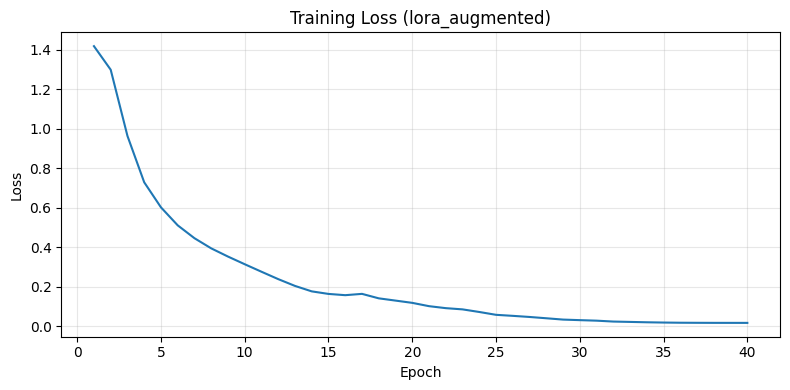

In [9]:
model, losses = train_lora(base_model, augmented_path, 'lora_augmented', epochs=EPOCHS, lr=LR)

## Step 5: Evaluate on Test Set

In [10]:
def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"primary_microconstituent"\s*:\s*"([\w+]+)"', raw)
    if dm: return {'primary_microconstituent': dm.group(1)}
    raw_lower = raw.lower()
    for cls in sorted(CLASSES, key=len, reverse=True):
        if cls in raw_lower: return {'primary_microconstituent': cls}
    return None

def evaluate(model, processor, manifest):
    model.eval()
    results = []; correct = 0; valid = 0; total_time = 0
    print(f'Evaluating on {len(manifest)} images...')
    for i, entry in enumerate(manifest):
        mag = entry.get('magnification', 'unknown')
        prompt = make_prompt(mag)
        image = Image.open(entry['image']).convert('RGB')
        msgs = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':prompt}]}]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt', padding=True).to(model.device)
        t = time.time()
        with torch.no_grad():
            ids = model.generate(**inputs, max_new_tokens=256, temperature=0.1, do_sample=True)
        elapsed = time.time() - t; total_time += elapsed
        out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
        parsed = parse_response(out)
        gt = entry['class']; ok = False
        if parsed:
            valid += 1
            pred = parsed.get('primary_microconstituent', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        results.append({'image': entry['image'], 'class': gt, 'magnification': mag,
            'predicted': parsed, 'raw': out, 'correct': ok,
            'valid_json': parsed is not None, 'time_s': round(elapsed, 2)})
        del inputs, ids; image.close(); torch.cuda.empty_cache()
        if (i+1) % 20 == 0:
            n = i+1; print(f'  [{n}/{len(manifest)}] Acc: {correct}/{n} ({correct/n*100:.0f}%)')
    return results, correct, valid, total_time

print('Eval functions ready.')

Eval functions ready.


In [11]:
with open(TEST_MANIFEST) as f:
    test_manifest = json.load(f)
print(f'Test set: {len(test_manifest)} images')

results, correct, valid, eval_time = evaluate(model, processor, test_manifest)
n = len(results)
print(f'\nSEAL LoRA: {correct}/{n} ({correct/n*100:.1f}%) | JSON: {valid}/{n} | {eval_time/n:.1f}s/img')

print(f'\nPer-class:')
by_class = defaultdict(list)
for r in results: by_class[r['class']].append(r)
for cls in CLASSES:
    cr = by_class[cls]; c = sum(1 for r in cr if r['correct'])
    print(f'  {cls:<30} {c:>3}/{len(cr)} ({c/len(cr)*100:.0f}%)') if cr else None

Test set: 120 images
Evaluating on 120 images...
  [20/120] Acc: 18/20 (90%)
  [40/120] Acc: 30/40 (75%)
  [60/120] Acc: 43/60 (72%)
  [80/120] Acc: 57/80 (71%)
  [100/120] Acc: 71/100 (71%)
  [120/120] Acc: 80/120 (67%)

SEAL LoRA: 80/120 (66.7%) | JSON: 120/120 | 3.2s/img

Per-class:
  spheroidite                     53/74 (72%)
  network                         16/20 (80%)
  spheroidite+widmanstatten        4/15 (27%)
  pearlite+spheroidite             4/5 (80%)
  pearlite                         3/3 (100%)


In [12]:
with open('results_augmented.json', 'w') as f:
    json.dump({'model': MODEL_ID, 'method': 'seal_augmented_lora', 'dataset': 'UHCS',
        'total_images': n, 'accuracy_pct': round(correct/n*100, 1),
        'json_validity_pct': round(valid/n*100, 1), 'avg_inference_time_s': round(eval_time/n, 2),
        'training_images': len(train_data), 'training_examples': len(augmented_data),
        'epochs': EPOCHS, 'lr': LR, 'results': results}, f, indent=2)
print('Saved results_augmented.json')

Saved results_augmented.json


## Comparison

In [13]:
print(f'{"Method":<35} {"Accuracy":>10}')
print('=' * 47)
print(f'{"Qwen base (ZS)":<35} {"60.8%":>10}')
print(f'{"GPT-4.1 ZS":<35} {"46.7%":>10}')
if os.path.exists('results_direct.json'):
    with open('results_direct.json') as f: d = json.load(f)
    print(f'{"Direct LoRA":<35} {d["accuracy_pct"]:>9.1f}%')
print(f'{"SEAL LoRA":<35} {correct/n*100:>9.1f}%')
print(f'{"GPT-4.1 FS (teacher)":<35} {"71.7%":>10}')
print(f'{"GPT-5 FS":<35} {"80.0%":>10}')
print(f'{"Random chance":<35} {"16.7%":>10}')

Method                                Accuracy
Qwen base (ZS)                           60.8%
GPT-4.1 ZS                               46.7%
Direct LoRA                              65.8%
SEAL LoRA                                66.7%
GPT-4.1 FS (teacher)                     71.7%
GPT-5 FS                                 80.0%
Random chance                            16.7%
